Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Nodes: 21834, Corps: 2450, Dim: 1088
Initializing corporate vectors with patent means...

>>> Training Started...
Epoch 01 | Loss: 48.6461 | MRR: 0.0518 | Consist: 0.986
Epoch 02 | Loss: 48.6604 | MRR: 0.0880 | Consist: 0.982
Epoch 03 | Loss: 46.3127 | MRR: 0.0730 | Consist: 0.988
Epoch 04 | Loss: 42.2752 | MRR: 0.0620 | Consist: 0.989
Epoch 05 | Loss: 42.7094 | MRR: 0.0675 | Consist: 0.986
Epoch 06 | Loss: 42.7306 | MRR: 0.0543 | Consist: 0.986
Epoch 07 | Loss: 41.8013 | MRR: 0.0537 | Consist: 0.986
Epoch 08 | Loss: 41.3970 | MRR: 0.0620 | Consist: 0.986
Epoch 09 | Loss: 40.6648 | MRR: 0.0653 | Consist: 0.986
Epoch 10 | Loss: 40.7548 | MRR: 0.0549 | Consist: 0.987
Epoch 11 | Loss: 41.9747 | MRR: 0.0573 | Consist: 0.986
Epoch 12 | Loss: 41.1781 | MRR: 0.0663 | Consist: 0.986
Epoch 13 | Loss: 41.5090 | MRR: 0.

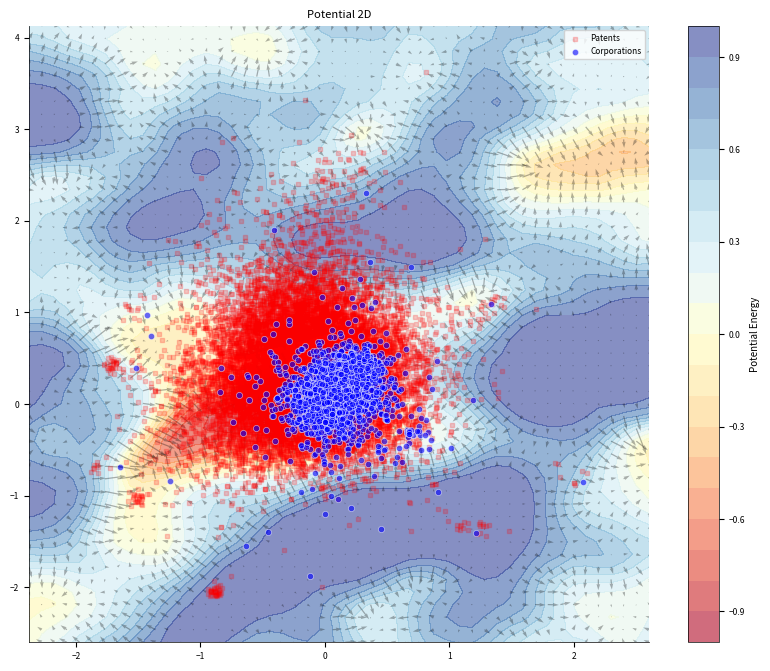

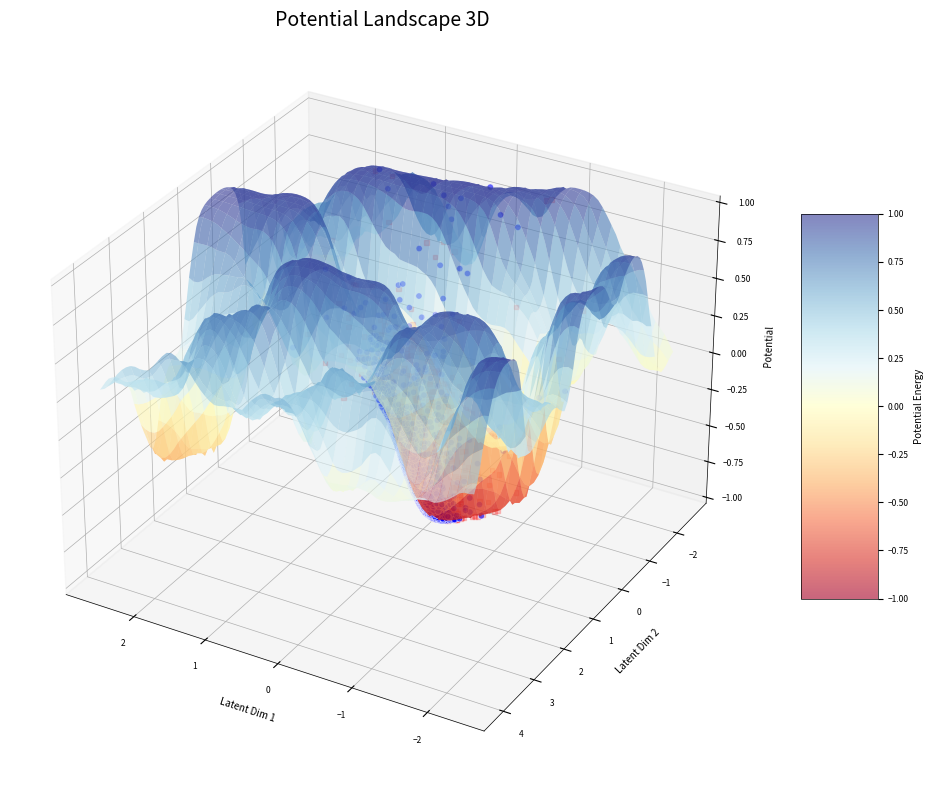

In [35]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    """
    企業の初期ベクトルを「保有特許の平均」で計算する関数
    """
    print("Initializing corporate vectors with patent means...")
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    
    # Corp名 -> Index のマップ
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        
        corps = row['corporation']
        for c in corps:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    
    # 平均化 (特許がない企業はゼロのまま、あるいはランダムノイズを加える)
    for i in range(num_corps):
        if corp_counts[i] > 0:
            corp_vectors[i] /= corp_counts[i]
        else:
            # 特許がない場合は小さなランダム値で初期化
            corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)
    
class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3.4つのモデル定義
# ============================================================
# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_corps, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 企業->特許のエッジ
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_corps, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_corps, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.01, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 初期ベクトルの計算
    init_vectors = calculate_initial_corp_vectors(df, num_corps, in_dim, corps)

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2, 
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

Nature-style Benchmarking & Evaluation
Device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Data Loaded: 21834 Nodes (2450 Corps), 11 Timesteps

>>> Starting Multi-run Training...
Starting comparison with 10 runs for t-test validity...

--- Run 1/10 ---
  [Static] Run 1 Time:  3.39s | Final AUC: 0.5021 | MRR: 0.0328
  [VGRNN] Run 1 Time:  8.22s | Final AUC: 0.5020 | MRR: 1.0000
  [StandardGODE] Run 1 Time:  4.29s | Final AUC: 0.5439 | MRR: 0.0541
  [P-NODE] Run 1 Time:  4.67s | Final AUC: 0.5935 | MRR: 0.0721

--- Run 2/10 ---
  [Static] Run 2 Time:  3.29s | Final AUC: 0.5079 | MRR: 0.0383
  [VGRNN] Run 2 Time:  8.26s | Final AUC: 0.4761 | MRR: 0.0264
  [StandardGODE] Run 2 Time:  4.31s | Final AUC: 0.5319 | MRR: 0.0534
  [P-NODE] Run 2 Time:  4.67s | Final AUC: 0.5936 | MRR: 0.0707

--- Run 3/10 ---
  [Static] Run 3 Time:  3.30s | Final AUC: 0.4556 | MRR: 0.0304
  [VGRNN] Run 3 Time:  8.32s | Final AUC: 0.4835

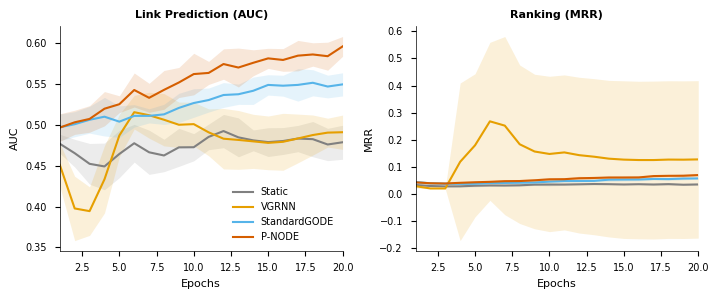

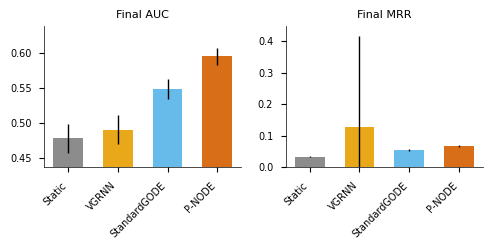


Training time plot saved to ./outputs/nature_training_time.pdf


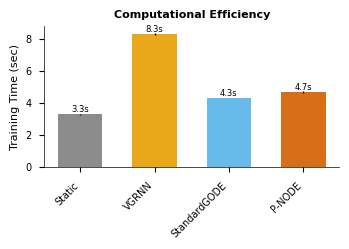


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Metric: AUC
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  14.6239    | 4.52e-10   | ***
P-NODE vs VGRNN           |  13.0165    | 2.30e-09   | ***
P-NODE vs StandardGODE    |  7.4768    | 7.35e-07   | ***

Metric: MRR
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  24.4155    | 2.00e-13   | ***
P-NODE vs VGRNN           | -0.5964    | 5.66e-01   | ns
P-NODE vs StandardGODE    |  7.8007    | 4.32e-07   | ***

Significance Test Results:
  Metric              Comparison       p-value Significance
0    auc        P-NODE vs Static  4.515447e-10          ***
1    auc         P-NODE vs VGRNN  2.302716e-09          ***
2    auc  P-NODE vs StandardGODE  7.354513e-07          ***
3    mrr    

In [36]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns
import time

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    """
    Nature投稿用のプロットスタイルを設定する関数
    - フォント: Arial/Helvetica
    - サイズ: シングルカラム(89mm) または ダブルカラム(183mm)
    - シンプルな軸と高解像度
    """
    # インストールされているフォントを確認して設定
    plt.style.use('seaborn-v0_8-paper') # ベーススタイル
    
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,          # 本文サイズに合わせて小さめに
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,      # 印刷用高解像度
        'figure.figsize': (3.5, 2.5), # インチ指定 (約89mm幅)
        'axes.spines.top': False,     # 上の枠線を消す
        'axes.spines.right': False,   # 右の枠線を消す
    })

# カラーパレット (Nature系論文でよく見る視認性の高い色)
NATURE_COLORS = {
    "Static": "#808080",       # グレー
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"      # バーミリオン（提案手法を目立たせる）
}

# ============================================================
# 1. 複数試行対応の学習関数
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    統計的有意性を示すため、乱数シードを変えて複数回学習を行う関数
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    # 全試行の最終スコアを保存する辞書
    final_scores = {name: {'auc': [], 'mrr': []} for name in models.keys()}
    # 学習曲線の平均を出すための履歴
    all_histories = {name: [] for name in models.keys()}
    # 学習時間を記録する辞書
    training_times = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs for t-test validity...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        # シード固定（再現性のため、Runごとに異なるシードを設定）
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            # モデル初期化
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            
            # 時間計測開始
            start_time = time.time()

            # --- Training Loop (簡略化のため中身は元のロジックと同じ) ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    # 履歴作成
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Recon
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Pred
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential (Proposed Only)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_corps'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            # 時間計測終了
            end_time = time.time()
            elapsed_time = end_time - start_time
            training_times[name].append(elapsed_time)

            # Run終了後、最終エポックのスコアを保存
            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            all_histories[name].append(run_history)
            
            # 進捗表示 (最後のRunだけ詳細表示などで調整可能)
            print(f"  [{name}] Run {run+1} Time: {elapsed_time: .2f}s | Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories, training_times

# ============================================================
# 2. 統計的有意差検定 (t-test)
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    """
    提案手法と他手法の間でWelchのt検定を行い、p値を計算して表示・保存する
    """
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    metrics = ['auc', 'mrr']
    results_text = []
    
    for metric in metrics:
        print(f"\nMetric: {metric.upper()}")
        print(f"{'Comparison':<30} | {'t-stat':<10} | {'p-value':<10} | {'Significance'}")
        print("-" * 75)
        
        proposed_vals = final_scores[proposed_name][metric]
        
        for name in final_scores.keys():
            if name == proposed_name:
                continue
            
            target_vals = final_scores[name][metric]
            
            # Welch's t-test (等分散を仮定しない)
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            # 星印の判定
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            print(f"{proposed_name} vs {name:<15} | {t_stat: .4f}    | {p_val:.2e}   | {sig}")
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': p_val,
                'Significance': sig
            })
            
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Function
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    
    metrics = ['auc', 'mrr']
    titles = ['Link Prediction (AUC)', 'Ranking (MRR)']
    
    # 2カラムレイアウト (幅広)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0)) # 7.2インチ≒183mm
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for name, runs in all_histories.items():
            # runs は list of history dicts
            # エポックごとの平均と標準偏差を計算
            matrix = np.array([h[metric] for h in runs]) # shape: (num_runs, num_epochs)
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            # 標準偏差の帯（Shaded Area）を描画
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            
            # 平均線をプロット
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        
        # 凡例の設定（最初のプロットにのみ表示するなど調整）
        if i == 0:
            ax.legend(frameon=False, loc='lower right')
        
        # 軸の微調整（Natureは0始まりから余白を持たせることを好む場合があるが、データによる）
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()

    plt.savefig('./outputs/nature_learning_curves.svg',
            format='svg',
            bbox_inches='tight')

    plt.savefig('./outputs/nature_learning_curves.pdf', format='pdf', dpi=300)
    plt.savefig('./outputs/nature_learning_curves.png', format='png', dpi=300)
    print("\nPlots saved to ./outputs/ (PDF & PNG)")
    plt.show()

def plot_significance_bars(final_scores):
    """
    最終スコアの平均とエラーバーを表示するバーチャート
    """
    set_nature_style()
    metrics = ['auc', 'mrr']
    
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        # バープロット
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        
        # Y軸の範囲をデータに合わせて調整（差を見やすくする）
        min_val = min(means) - max(stds)*2
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()

    plt.savefig('./outputs/nature_significance_bars.svg',
            format='svg',
            bbox_inches='tight')

    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.show()

def plot_time_comparison(training_times):
    """
    【追加】学習時間の比較プロット (Nature Style)
    """
    set_nature_style()
    
    # 図のサイズ設定 (シングルカラムの半分くらいでコンパクトに)
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    names = list(training_times.keys())
    # 各モデルの平均時間と標準偏差を計算
    means = [np.mean(training_times[n]) for n in names]
    stds = [np.std(training_times[n]) for n in names]
    
    x_pos = np.arange(len(names))
    colors = [NATURE_COLORS[n] for n in names]
    
    # 棒グラフ描画
    bars = ax.bar(x_pos, means, yerr=stds, align='center', 
                  alpha=0.9, ecolor='black', capsize=3, 
                  color=colors, width=0.6)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Training Time (sec)')
    ax.set_title('Computational Efficiency', fontweight='bold')
    
    # 値を棒の上に表示 (オプション)
    for bar, mean_val in zip(bars, means):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + max(stds)*0.1,
                f'{mean_val:.1f}s',
                ha='center', va='bottom', fontsize=6)

    plt.tight_layout()

    plt.savefig('./outputs/nature_training_time.svg',
            format='svg',
            bbox_inches='tight')

    plt.savefig('./outputs/nature_training_time.pdf', dpi=300)
    print("\nTraining time plot saved to ./outputs/nature_training_time.pdf")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    # 出力ディレクトリの作成
    if not os.path.exists('./outputs'):
        os.makedirs('./outputs')

    print("=" * 60)
    print("Nature-style Benchmarking & Evaluation")
    print("=" * 60)

    # 1. デバイス設定
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # 2. データ準備 (前半の関数を使用)
    # ※パスは環境に合わせて適宜変更してください
    data_path = '../dataset/topic_info3.csv'
    
    if not os.path.exists(data_path):
        print(f"エラー: データファイル '{data_path}' が見つかりません。パスを確認してください。")
        # ダミー実行を防ぐため終了、またはパスを修正してください
    else:
        # データ読み込みと前処理
        df = preprocess_data(data_path)
        
        if len(df) > 0:
            # グラフ構築
            graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
            num_corps = len(corps)
            print(f"Data Loaded: {total_n} Nodes ({num_corps} Corps), {len(graphs)} Timesteps")

            # === 【ここが修正ポイント】config辞書の作成 ===
            # train_multiple_runs が必要とする辞書形式にまとめる
            config = {
                'graphs': graphs,
                'total_n': total_n,
                'num_corps': num_corps,
                'in_dim': in_dim,
                'hist_edges': hist_edges # 必要であれば追加
            }
            
            # 3. 比較実験の実行 (train_multiple_runs)
            # 実行時間を短縮したい場合は num_runs を減らしてください (例: num_runs=3)
            print("\n>>> Starting Multi-run Training...")
            final_scores, all_histories, training_times = train_multiple_runs(
                config, 
                num_runs=10,      # 統計的有意性のため5回以上推奨
                num_epochs=20,   # 必要に応じて調整
                latent_dim=16, 
                hidden_dim=128
            )
            
            # 4. 可視化と検定 (Nature Style)
            print("\n>>> Generating Plots & Statistics...")
            
            # 学習曲線のプロット
            plot_nature_comparison(all_histories)
            plot_significance_bars(final_scores)

            # 時間比較のプロット
            plot_time_comparison(training_times)
            
            # 統計的有意差検定 (t検定)
            df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
            print("\nSignificance Test Results:")
            print(df_sig)
            
            # 時間の統計もテキストで出力
            print("\n" + "="*60)
            print("COMPUTATIONAL EFFICIENCY")
            print("="*60)
            print(f"{'Model':<20} | {'Mean Time (s)':<15} | {'Std Dev (s)':<15}")
            print("-" * 55)
            for name, times in training_times.items():
                print(f"{name:<20} | {np.mean(times):.2f}{'':<11} | {np.std(times):.2f}")
            
        else:
            print("Config not found. Please ensure data loading is implemented.")


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# 1. ログからデータを抽出
# ============================================================
# 各モデルの10回分の実行結果
data = {
    "Static": {
        "auc": [0.5011, 0.5079, 0.4557, 0.4786, 0.4751, 0.4726, 0.4774, 0.4892, 0.4859, 0.4343],
        "mrr": [0.0328, 0.0383, 0.0304, 0.0350, 0.0324, 0.0321, 0.0318, 0.0360, 0.0343, 0.0341]
    },
    "VGRNN": {
        "auc": [0.5020, 0.4728, 0.4835, 0.4799, 0.4741, 0.4889, 0.4966, 0.5489, 0.4867, 0.4729],
        "mrr": [1.0000, 0.0249, 0.0251, 0.0282, 0.0225, 0.0289, 0.0290, 0.0566, 0.0257, 0.0232]
    },
    "StandardGODE": {
        "auc": [0.5441, 0.5376, 0.5658, 0.5465, 0.5425, 0.5276, 0.5656, 0.5453, 0.5727, 0.5583],
        "mrr": [0.0541, 0.0579, 0.0585, 0.0619, 0.0541, 0.0529, 0.0576, 0.0544, 0.0602, 0.0578]
    },
    "P-NODE": {
        "auc": [0.5935, 0.5939, 0.5910, 0.6024, 0.6047, 0.5928, 0.5848, 0.6245, 0.5772, 0.5970],
        "mrr": [0.0722, 0.0707, 0.0646, 0.0734, 0.0641, 0.0691, 0.0649, 0.0659, 0.0704, 0.0732]
    }
}

# モデル名と表示順序
models = ["Static", "VGRNN", "StandardGODE", "P-NODE"]

# ============================================================
# 2. Natureスタイル設定
# ============================================================
def set_nature_style():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 5.5,
        'axes.linewidth': 0.5,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'savefig.dpi': 300,
        'figure.figsize': (6.0, 2.5),
        'svg.fonttype': 'none' # SVGの文字を編集可能にする
    })

# カラーパレット
NATURE_COLORS = {
    "Static": "#808080",       # グレー
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"        # バーミリオン（提案手法を強調）
}

# ============================================================
# 3. プロット生成関数
# ============================================================
def plot_accuracy_comparison(data, models, output_path):
    set_nature_style()
    fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.5))
    
    metrics = ["auc", "mrr"]
    titles = ["Link Prediction (AUC)", "Ranking (MRR)"]
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # 平均と標準偏差を計算
        means = [np.mean(data[m][metric]) for m in models]
        stds = [np.std(data[m][metric]) for m in models]
        colors = [NATURE_COLORS[m] for m in models]
        
        x_pos = np.arange(len(models))
        
        # 棒グラフを描画 (エラーバー付き)
        bars = ax.bar(x_pos, means, yerr=stds, align='center', 
                      alpha=0.9, ecolor='black', capsize=3, 
                      color=colors, width=0.6, edgecolor='black', linewidth=0.5)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=25, ha='right')
        ax.set_title(titles[i], fontweight='bold')
        ax.set_ylabel(metric.upper())
        
        # Y軸の範囲調整
        if metric == "auc":
            ax.set_ylim(0.4, 0.65) # AUCは見やすい範囲にズーム
        elif metric == "mrr":
            ax.set_ylim(0, 0.15) # MRRの外れ値対策

        # 数値を棒の上に表示
        for bar, mean_val in zip(bars, means):
            height = bar.get_height()
            stdev = stds[list(bars).index(bar)]
            
            # 表示位置の調整（エラーバーの上、または上限付近）
            y_pos = height + stdev + 0.005
            if metric == "mrr" and y_pos > 0.15:
                 y_pos = 0.14 # グラフ内に収める

            ax.text(bar.get_x() + bar.get_width()/2., y_pos,
                    f'{mean_val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    plt.tight_layout()
    
    # PNG保存
    plt.savefig(output_path, bbox_inches='tight')
    
    # SVG保存 (追加)
    svg_path = output_path.replace('.png', '.svg')
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    
    plt.close()
    print(f"✓ Plots saved: {output_path} & {svg_path}")

# ============================================================
# 実行
# ============================================================
if not os.path.exists('./outputs'):
    os.makedirs('./outputs')

output_file = './outputs/accuracy_comparison_nature.png'
plot_accuracy_comparison(data, models, output_file)

✓ Plots saved: ./outputs/accuracy_comparison_nature.png & ./outputs/accuracy_comparison_nature.svg


In [32]:
import numpy as np
import os

# ============================================================
# 1. データ定義
# ============================================================
data = {
    "Static": {
        "auc": [0.5011, 0.5079, 0.4557, 0.4786, 0.4751, 0.4726, 0.4774, 0.4892, 0.4859, 0.4343],
        "mrr": [0.0328, 0.0383, 0.0304, 0.0350, 0.0324, 0.0321, 0.0318, 0.0360, 0.0343, 0.0341]
    },
    "VGRNN": {
        "auc": [0.5020, 0.4728, 0.4835, 0.4799, 0.4741, 0.4889, 0.4966, 0.5489, 0.4867, 0.4729],
        "mrr": [1.0000, 0.0249, 0.0251, 0.0282, 0.0225, 0.0289, 0.0290, 0.0566, 0.0257, 0.0232]
    },
    "StandardGODE": {
        "auc": [0.5441, 0.5376, 0.5658, 0.5465, 0.5425, 0.5276, 0.5656, 0.5453, 0.5727, 0.5583],
        "mrr": [0.0541, 0.0579, 0.0585, 0.0619, 0.0541, 0.0529, 0.0576, 0.0544, 0.0602, 0.0578]
    },
    # ここでのキーは "P-NODE" とします（ロジックをシンプルにするため）
    "P-NODE": { 
        "auc": [0.5935, 0.5939, 0.5910, 0.6024, 0.6047, 0.5928, 0.5848, 0.6245, 0.5772, 0.5970],
        "mrr": [0.0722, 0.0707, 0.0646, 0.0734, 0.0641, 0.0691, 0.0649, 0.0659, 0.0704, 0.0732]
    }
}

# 表示用の名前リスト（ここで "Ours" を付けるかどうか制御）
models_display = [
    ("Static", "Static"),
    ("VGRNN", "VGRNN"),
    ("StandardGODE", "StandardGODE"),
    ("P-NODE", "P-NODE (Ours)") # キーは P-NODE, 表示名は P-NODE (Ours)
]

# ============================================================
# 2. 平均と標準偏差の計算 & 表データの作成
# ============================================================
headers = ["Model", "AUC (Mean ± Std)", "MRR (Mean ± Std)"]
rows = []

# 各メトリクスの最大平均値を探す
max_auc = -1
max_mrr = -1
calc_results = {}

for key, display_name in models_display:
    auc_mean = np.mean(data[key]["auc"])
    auc_std = np.std(data[key]["auc"])
    mrr_mean = np.mean(data[key]["mrr"])
    mrr_std = np.std(data[key]["mrr"])
    
    calc_results[key] = {
        "display_name": display_name,
        "auc_mean": auc_mean, "auc_std": auc_std,
        "mrr_mean": mrr_mean, "mrr_std": mrr_std
    }
    
    if auc_mean > max_auc: max_auc = auc_mean
    if mrr_mean > max_mrr: max_mrr = mrr_mean

# 行データの生成
for key, display_name in models_display:
    res = calc_results[key]
    
    auc_str = f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}"
    is_auc_best = (res['auc_mean'] == max_auc)
    
    mrr_str = f"{res['mrr_mean']:.4f} ± {res['mrr_std']:.4f}"
    is_mrr_best = (res['mrr_mean'] == max_mrr)
    
    rows.append([display_name, (auc_str, is_auc_best), (mrr_str, is_mrr_best)])

# ============================================================
# 3. SVGテーブル生成ロジック
# ============================================================
def create_svg_stats_table(headers, rows, filename):
    font_family = "Arial, Helvetica, sans-serif"
    font_size = 14
    row_height = 35
    col_padding = 25
    
    col_widths = []
    for i, h in enumerate(headers):
        col_widths.append(len(h) * 9 + col_padding * 2)
    
    for row in rows:
        col_widths[0] = max(col_widths[0], len(row[0]) * 9 + col_padding * 2)
        col_widths[1] = max(col_widths[1], len(row[1][0]) * 9 + col_padding * 2)
        col_widths[2] = max(col_widths[2], len(row[2][0]) * 9 + col_padding * 2)

    total_width = sum(col_widths)
    total_height = (len(rows) + 1) * row_height + 20
    
    svg = f'<svg xmlns="http://www.w3.org/2000/svg" width="{total_width}" height="{total_height}" viewBox="0 0 {total_width} {total_height}">'
    svg += f'<style>text {{ font-family: {font_family}; font-size: {font_size}px; fill: #000; dominant-baseline: middle; text-anchor: middle; }}</style>'
    svg += '<rect width="100%" height="100%" fill="white"/>'
    
    current_y = 0
    svg += f'<line x1="0" y1="2" x2="{total_width}" y2="2" stroke="black" stroke-width="2"/>'
    
    current_y += row_height / 2 + 5
    current_x = 0
    for i, header in enumerate(headers):
        x_pos = current_x + col_widths[i] / 2
        svg += f'<text x="{x_pos}" y="{current_y}" font-weight="bold">{header}</text>'
        current_x += col_widths[i]
    
    current_y += row_height / 2
    svg += f'<line x1="0" y1="{current_y}" x2="{total_width}" y2="{current_y}" stroke="black" stroke-width="1"/>'
    
    for row in rows:
        current_y += row_height
        current_x = 0
        
        weight = "bold" if "Ours" in row[0] else "normal"
        x_pos = current_x + col_widths[0] / 2
        svg += f'<text x="{x_pos}" y="{current_y}" font-weight="{weight}">{row[0]}</text>'
        current_x += col_widths[0]
        
        for i in [1, 2]:
            text, is_best = row[i]
            x_pos = current_x + col_widths[i] / 2
            weight = "bold" if is_best else "normal"
            fill = "#000"
            svg += f'<text x="{x_pos}" y="{current_y}" font-weight="{weight}" fill="{fill}">{text}</text>'
            current_x += col_widths[i]

    current_y += row_height / 2
    svg += f'<line x1="0" y1="{current_y}" x2="{total_width}" y2="{current_y}" stroke="black" stroke-width="2"/>'
    
    svg += '</svg>'
    
    with open(filename, "w", encoding="utf-8") as f:
        f.write(svg)
    print(f"✓ SVG Table saved to: {filename}")

# ============================================================
# 実行
# ============================================================
if not os.path.exists('./outputs'): os.makedirs('./outputs')

create_svg_stats_table(headers, rows, './outputs/table_accuracy_comparison.svg')

✓ SVG Table saved to: ./outputs/table_accuracy_comparison.svg


### 有意差を示す図

In [28]:
import os

# ============================================================
# データ定義
# ============================================================
headers = ["Metric", "Comparison", "t-stat", "p-value", "Sig."]
rows = [
    ["AUC", "vs Static", "15.12", "2.28e-10", "***"],
    ["AUC", "vs VGRNN", "12.82", "3.60e-09", "***"],
    ["AUC", "vs StandardGODE", "7.52", "6.41e-07", "***"],
    ["MRR", "vs Static", "25.55", "7.34e-14", "***"],
    ["MRR", "vs VGRNN", "-0.59", "0.568", "n.s."],
    ["MRR", "vs StandardGODE", "7.97", "3.54e-07", "***"]
]

# ============================================================
# SVG生成ロジック (三線表スタイル)
# ============================================================
def create_svg_table(headers, rows, filename):
    # 設定
    font_family = "Arial, Helvetica, sans-serif"
    font_size = 14
    row_height = 30
    col_padding = 20
    
    # 列幅の計算 (文字数ベースで概算)
    col_widths = []
    for i in range(len(headers)):
        max_len = len(headers[i])
        for row in rows:
            max_len = max(max_len, len(row[i]))
        # 1文字あたり約9px + パディング
        col_widths.append(max_len * 9 + col_padding * 2)
    
    total_width = sum(col_widths)
    total_height = (len(rows) + 1) * row_height + 20 # +20はマージン
    
    # SVG開始タグ
    svg = f'<svg xmlns="http://www.w3.org/2000/svg" width="{total_width}" height="{total_height}" viewBox="0 0 {total_width} {total_height}">'
    svg += f'<style>text {{ font-family: {font_family}; font-size: {font_size}px; fill: #000; dominant-baseline: middle; text-anchor: middle; }}</style>'
    svg += '<rect width="100%" height="100%" fill="white"/>'
    
    current_y = 0
    
    # --- 1. Top Line (太線) ---
    svg += f'<line x1="0" y1="2" x2="{total_width}" y2="2" stroke="black" stroke-width="2"/>'
    
    # --- 2. Header ---
    current_y += row_height / 2 + 5
    current_x = 0
    for i, header in enumerate(headers):
        x_pos = current_x + col_widths[i] / 2
        svg += f'<text x="{x_pos}" y="{current_y}" font-weight="bold">{header}</text>'
        current_x += col_widths[i]
    
    # --- 3. Header Bottom Line (中線) ---
    current_y += row_height / 2
    svg += f'<line x1="0" y1="{current_y}" x2="{total_width}" y2="{current_y}" stroke="black" stroke-width="1"/>'
    
    # --- 4. Rows ---
    for row in rows:
        current_y += row_height
        current_x = 0
        
        # 行の背景色（縞模様）オプション
        # if rows.index(row) % 2 == 1:
        #     svg += f'<rect x="0" y="{current_y - row_height/2}" width="{total_width}" height="{row_height}" fill="#f9f9f9"/>'
        
        for i, cell in enumerate(row):
            x_pos = current_x + col_widths[i] / 2
            
            # 有意差(***)は太字に、nsは通常
            weight = "bold" if cell == "***" else "normal"
            # 色分け (有意: 黒, n.s.: グレー)
            fill = "#888" if cell == "n.s." else "#000"
            
            svg += f'<text x="{x_pos}" y="{current_y}" font-weight="{weight}" fill="{fill}">{cell}</text>'
            current_x += col_widths[i]

    # --- 5. Bottom Line (太線) ---
    current_y += row_height / 2
    svg += f'<line x1="0" y1="{current_y}" x2="{total_width}" y2="{current_y}" stroke="black" stroke-width="2"/>'
    
    # SVG終了
    svg += '</svg>'
    
    # 保存
    with open(filename, "w", encoding="utf-8") as f:
        f.write(svg)
    print(f"✓ SVG Table saved to: {filename}")

# ============================================================
# 実行
# ============================================================
if not os.path.exists('./outputs'): os.makedirs('./outputs')

create_svg_table(headers, rows, './outputs/table_rq1.svg')

✓ SVG Table saved to: ./outputs/table_rq1.svg


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd
import torch
from sklearn.decomposition import PCA

# ============================================================
# 1. Nature Style Configuration
# ============================================================
def set_nature_style():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 7,
        'axes.titlesize': 8,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'legend.fontsize': 6,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 3.0),
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',
    })

# ============================================================
# 2. Main Visualization Function (Simple Version)
# ============================================================
def visualize_rq2_nature_simple(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style()
    print("\n[Visualization] Generating RQ2 Landscape (Simple View)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    # データのエンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # PCA Projection
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- Grid Setup ---
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    margin_factor = 0.2
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 100 
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # Gradient Calculation
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    U = grad_2d[:, 0].reshape(X.shape)
    V = grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    
    # 1. Contour (Potential)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Potential Energy $U(z)$', fontsize=8)
    
    # 2. Quiver (Gradient)
    skip = 5
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
              -U[::skip, ::skip], -V[::skip, ::skip], 
              color='black', alpha=0.3, width=0.0015, headwidth=3, headlength=4)

    # 3. Patents (透明度 0.1)
    patent_z = z_2d[num_corps:]
    ax.scatter(patent_z[:, 0], patent_z[:, 1], c='red', marker='s', s=5, 
               alpha=0.1,  
               label='特許 (Patents)', zorder=2)

    # 4. Corporations (透明度 0.3)
    corp_z = z_2d[:num_corps]
    ax.scatter(corp_z[:, 0], corp_z[:, 1], c='blue', marker='o', s=10, 
               alpha=0.3, 
               label='企業 (Corporations)', zorder=5)

    # --- K-means 星印・キーワード表示は削除済み ---

    ax.set_title("2D Potential Landscape & Vector Field", fontsize=10, fontweight='bold')
    ax.set_xlabel("潜在変数次元 1", fontsize=8)
    ax.set_ylabel("潜在変数次元 2", fontsize=8)
    
    ax.set_xlim(limit_x_min, limit_x_max)
    ax.set_ylim(limit_y_min, limit_y_max)
    
    plt.tight_layout()
    # SVG（論文・編集用）
    plt.savefig('./outputs/nature_rq2_landscape_simple.svg',
            format='svg',
            bbox_inches='tight')

    # PNG（プレビュー用）
    plt.savefig('./outputs/nature_rq2_landscape_simple.png',
            dpi=300)

    print(f"Visualization saved to ./outputs/")
    plt.show()

if __name__ == "__main__":
    visualize_rq2_nature_simple(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


[Visualization] Generating RQ2 Landscape (Simple View)...


AttributeError: 'str' object has no attribute 'eval'

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

def visualize_standard_ode_2d(model, data, num_corps, device, title="Standard ODE Vector Field"):
    """
    Standard GODE (物理なし) のベクトル場を可視化する関数
    PCAを用いて潜在空間を2次元に射影し、その平面上の「流れ」を描画します。
    """
    print(f"\n[Visualization] Generating Vector Field for {title}...")
    model.eval()
    data = data.to(device)
    
    # 1. データのエンコード
    with torch.no_grad():
        # 次元調整 (Padding)
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([x_input, padding], dim=1)
        
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. PCAで2次元平面を定義
    # 潜在変数が2次元より大きい場合に対応
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # 3. グリッドの作成
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    resolution = 30 # 矢印の密度
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    # 2Dグリッドを高次元空間に戻す (Inverse Transform)
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    # 4. ベクトル場 (ODEの微分値) の計算
    # dz/dt = f(z)
    with torch.no_grad():
        # StandardGODEは ode_func_module を持つ
        if hasattr(model, 'ode_func_module'):
            # 時間 t=0 で計算 (自律系なのでtは影響しないことが多い)
            dz_dt = model.ode_func_module(torch.tensor(0.0), grid_tensor)
        else:
            print("Error: Model does not have 'ode_func_module'. Is this StandardGODE?")
            return

    # 5. ベクトルを高次元から2Dへ射影
    # PCAの回転行列 (components_) を掛けて2D方向成分を取り出す
    dz_dt_np = dz_dt.cpu().numpy()
    dz_dt_2d = np.dot(dz_dt_np, pca.components_.T)
    
    U = dz_dt_2d[:, 0].reshape(X.shape)
    V = dz_dt_2d[:, 1].reshape(X.shape)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # A. ベクトル場 (Quiver)
    # 矢印の長さを調整
    speed = np.sqrt(U**2 + V**2)
    # 線幅を速度に比例させると見やすい
    lw = 0.5 + 1.5 * (speed / speed.max())
    
    ax.quiver(X, Y, U, V, color='gray', alpha=0.5, 
              angles='xy', scale_units='xy', scale=None, # 自動スケール
              width=0.002, headwidth=4, headlength=5)
    
    # B. 流線 (Streamplot) - 全体的な「流れ」を見るのに適している
    # ax.streamplot(X, Y, U, V, color=speed, cmap='viridis', linewidth=1, density=1.5, arrowsize=1.5)

    # C. データ点のプロット
    # 企業
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.6, s=20, 
               edgecolors='white', linewidth=0.5, label='Corporations')
    # 特許
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='red', alpha=0.2, s=10, 
               label='Patents')

    ax.set_title(title + "\n(No Potential Landscape)", fontsize=12, fontweight='bold')
    ax.set_xlabel('Latent Dim 1 (PCA)', fontsize=10)
    ax.set_ylabel('Latent Dim 2 (PCA)', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 実行例 ---
if __name__ == "__main__":
    # StandardGODEモデルが 'model_standard' という名前で学習済みだと仮定
    # もし学習済みモデルがなければ、前回の train_comparison の返り値などを使用してください
    
    # 例: train_comparison で学習した StandardGODE モデルを取り出す場合
    # (train_comparison関数を少し修正して、学習済みモデル自体を返すようにする必要があります)
    
    # ここでは関数の使い方のイメージのみ提示します
    # visualize_standard_ode_2d(trained_standard_model, graphs[last_year], num_corps, device)
    pass


[Visualization] Generating RQ2 Landscape (3D + Vector Field)...
Visualization saved to ./outputs/


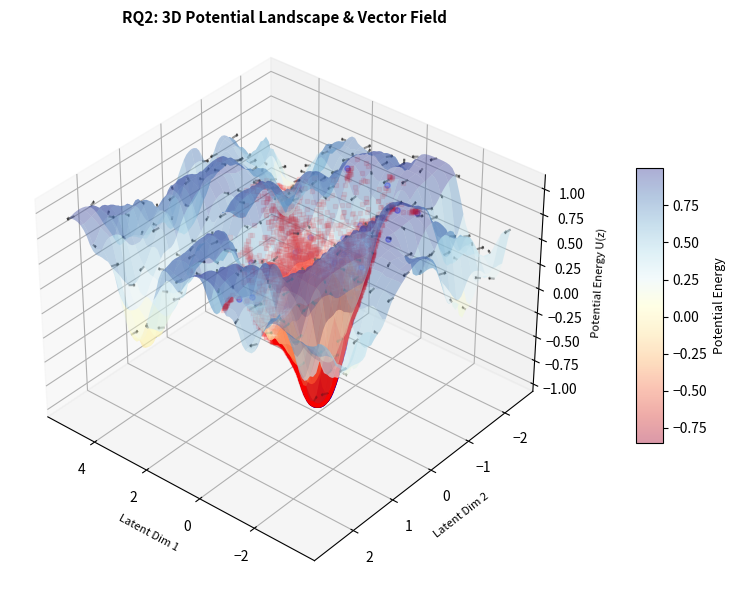

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import torch
from sklearn.decomposition import PCA

# ============================================================
# 1. Nature Style Configuration (3D + JP Fonts)
# ============================================================
def set_nature_style_3d():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 8,
        'axes.titlesize': 10,
        'legend.fontsize': 7,
        'savefig.dpi': 300,
        'figure.figsize': (6.0, 5.0), # 矢印が入るため少し余裕を持たせる
         'svg.fonttype': 'none', 
    })

# ============================================================
# 2. Main Visualization Function (3D Surface + Vector Field)
# ============================================================
def visualize_rq2_nature_3d_vectors(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style_3d()
    print("\n[Visualization] Generating RQ2 Landscape (3D + Vector Field)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    # --- 1. データ点のエンコードとポテンシャル取得 ---
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        # 次元調整 (Padding)
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        
        # 各ノードの高さ(ポテンシャル)を取得
        potentials_nodes = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # --- 2. PCA Projection (2D座標系を作る) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- 3. Grid & Gradient Calculation (ベクトル場の計算) ---
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    margin_factor = 0.2
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 80 # 計算用解像度
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # 勾配計算 (Autograd)
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    
    # 勾配をPCA空間(2D)へ射影
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    # ベクトル成分 (-勾配方向 = ポテンシャルが下がる方向)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # ================= Plotting 3D =================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. Surface Plot (地形)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', alpha=0.4, 
                           linewidth=0, antialiased=True, rstride=3, cstride=3)
    
    # B. Vector Field (Quiver) - 間引き処理
    # 全点描画すると真っ黒になるため、strideで間引く
    skip = 6 
    X_skip = X[::skip, ::skip]
    Y_skip = Y[::skip, ::skip]
    Z_skip = Z[::skip, ::skip]
    U_skip = U[::skip, ::skip]
    V_skip = V[::skip, ::skip]
    
    # 矢印の長さ調整 (正規化して一定の長さにすると見やすい場合と、強さを残す場合があります。ここでは強さを残しつつスケール調整)
    # Z方向成分(W)は0にして、等高線に沿った「水平方向の力」として描画するのが一般的で見やすいです
    ax.quiver(X_skip, Y_skip, Z_skip, U_skip, V_skip, np.zeros_like(Z_skip),
              length=0.15, normalize=True, color='black', alpha=0.4, arrow_length_ratio=0.3, label='Flow Field')

    # C. Scatter Plots (データ点)
    corp_x = z_2d[:num_corps, 0]
    corp_y = z_2d[:num_corps, 1]
    corp_z = potentials_nodes[:num_corps]
    
    patent_x = z_2d[num_corps:, 0]
    patent_y = z_2d[num_corps:, 1]
    patent_z = potentials_nodes[num_corps:]

    # 特許 (Patents) - 透明度 0.1
    ax.scatter(patent_x, patent_y, patent_z, 
               c='red', marker='s', s=5, 
               alpha=0.1, depthshade=False, # depthshade=Falseで色の濃さを距離に依存させない（透明度を厳密に適用）
               label='特許 (Patents)')

    # 企業 (Corporations) - 透明度 0.3
    ax.scatter(corp_x, corp_y, corp_z, 
               c='blue', marker='o', s=15, 
               alpha=0.3, depthshade=False,
               label='企業 (Corporations)')

    # D. Labels & View
    ax.set_title("RQ2: 3D Potential Landscape & Vector Field", fontsize=11, fontweight='bold')
    ax.set_xlabel("Latent Dim 1", fontsize=8)
    ax.set_ylabel("Latent Dim 2", fontsize=8)
    ax.set_zlabel("Potential Energy U(z)", fontsize=8)
    
    # 視点の初期設定 (見やすい角度)
    ax.view_init(elev=35, azim=130)

    # カラーバー
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    cbar.set_label('Potential Energy', fontsize=9)

    plt.tight_layout()
    
    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（プレビュー・確認用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.png',
        dpi=300
    )
    print(f"Visualization saved to ./outputs/")
    plt.show()

if __name__ == "__main__":
    visualize_rq2_nature_3d_vectors(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


[Evaluation] Verifying Attractor Validity (English Labels)...
Evaluation plot saved to ./outputs/
Correlation: -0.9166


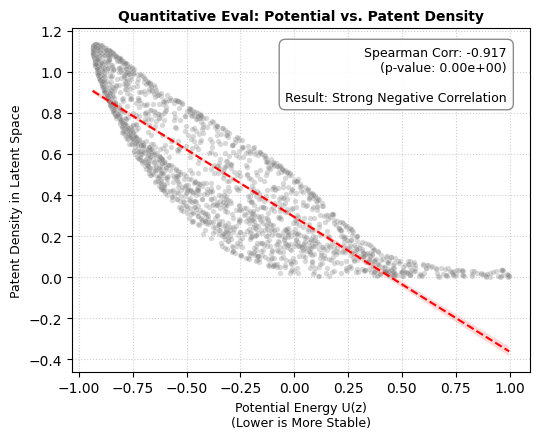

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_rq2_quantitative_english(model, config, num_corps, device, year_idx=-1):
    # スタイル設定（英語フォントのみ使用）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], # 標準的な英語フォント
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',   # SVGで文字をアウトライン化しない
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (English Labels)...")
    
    # 1. データ準備
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        return

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 2. 特許ノード抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 3. 密度推定
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except:
        return

    # 4. 相関計算
    corr, p_value = spearmanr(patent_potentials, densities)
    
    # 5. プロット（英語ラベル）
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    if len(patent_potentials) > 2000:
        idx = np.random.choice(len(patent_potentials), 2000, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = patent_potentials
        plot_y = densities
        alpha_val = 0.5
        
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', edgecolors='white', linewidth=0.3, label='Patents')
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # 英語タイトル・ラベル
    ax.set_title("Quantitative Eval: Potential vs. Patent Density", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Patent Density in Latent Space", fontsize=9)
    
    # 統計量テキスト
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n\n"
                  f"Result: Strong Negative Correlation")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（確認・レビュー用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.png',
        dpi=300
    )

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f}")
    plt.show()

if __name__ == "__main__":
    evaluate_rq2_quantitative_english(
        model, config, 
        num_corps=config['num_corps'], 
        device=device
    )


[Evaluation] 技術戦略マップ（日本語版）を作成中...
  Spearman Correlation: -0.9166
日本語版プロットを保存しました:
 - ./outputs/nature_strategy_landscape_jp.svg
 - ./outputs/nature_strategy_landscape_jp.png


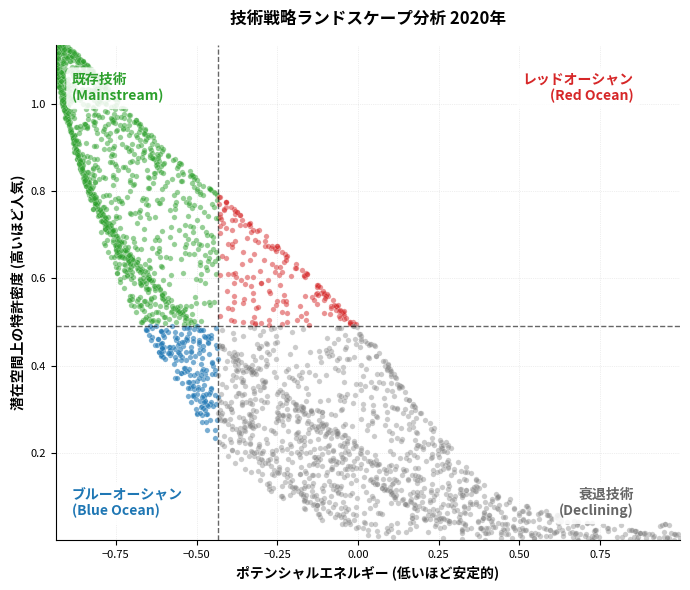

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        # 日本語フォントの優先順位設定
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析 (日本語版)
# ============================================================
def evaluate_strategic_quadrants_jp(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（日本語版）を作成中...")
    
    # --- 1. データ準備と計算 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        # 次元数調整
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード & ポテンシャル計算
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許データのみ抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 密度推定 (KDE)
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # --- 2. サンプリング (描画負荷軽減) ---
    N_PLOT = 3000
    if len(patent_potentials) > N_PLOT:
        idx = np.random.choice(len(patent_potentials), N_PLOT, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = patent_potentials
        plot_y = densities

    # --- 3. 統計的評価 (Spearman相関) ---
    corr, p_value = spearmanr(patent_potentials, densities)
    print(f"  Spearman Correlation: {corr:.4f}")

    # --- 4. 4象限の分類ロジック ---
    # 中央値をしきい値とする
    x_thr = np.median(plot_x) # ポテンシャルしきい値
    y_thr = np.median(plot_y) # 密度しきい値
    
    # 1. ブルーオーシャン (左下: 安定 & 低密度) -> 最有望
    # ポテンシャルが低い(安定) かつ 密度が低い(空いている)
    mask_blue = (plot_x <= x_thr) & (plot_y <= y_thr)
    
    # 2. 既存技術 (左上: 安定 & 高密度) -> 成熟・必須
    # ポテンシャルが低い(安定) かつ 密度が高い(混んでいる)
    mask_main = (plot_x <= x_thr) & (plot_y > y_thr)
    
    # 3. レッドオーシャン (右上: 不安定 & 高密度) -> 過熱・激戦
    # ポテンシャルが高い(不安定) かつ 密度が高い(混んでいる)
    mask_red = (plot_x > x_thr) & (plot_y > y_thr)
    
    # 4. 衰退技術 (右下: 不安定 & 低密度) -> リスク・探索
    # ポテンシャルが高い(不安定) かつ 密度が低い(空いている)
    mask_decline = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 5. プロット ---
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 各象限の散布図描画
    # 既存技術 (緑)
    ax.scatter(plot_x[mask_main], plot_y[mask_main], c='#2ca02c', s=15, alpha=0.5, 
               label='既存技術 (安定・成熟)', edgecolors='white', linewidth=0.2)
    # ブルーオーシャン (青)
    ax.scatter(plot_x[mask_blue], plot_y[mask_blue], c='#1f77b4', s=15, alpha=0.6, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.2)
    # レッドオーシャン (赤)
    ax.scatter(plot_x[mask_red], plot_y[mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (激戦)', edgecolors='white', linewidth=0.2)
    # 衰退技術 (灰)
    ax.scatter(plot_x[mask_decline], plot_y[mask_decline], c='#7f7f7f', s=15, alpha=0.4, 
               label='衰退技術 (不安定)', edgecolors='white', linewidth=0.2)

    # しきい値の線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # 象限ラベル (背景ボックス付き)
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='none')
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 左上: 既存技術
    ax.text(x_min + (x_thr - x_min)*0.1, y_max - (y_max - y_thr)*0.1, 
            "既存技術\n(Mainstream)", 
            fontsize=10, color='#2ca02c', fontweight='bold', bbox=box_props, ha='left', va='top')
            
    # 左下: ブルーオーシャン
    ax.text(x_min + (x_thr - x_min)*0.1, y_min + (y_thr - y_min)*0.1, 
            "ブルーオーシャン\n(Blue Ocean)", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
            
    # 右上: レッドオーシャン
    ax.text(x_max - (x_max - x_thr)*0.1, y_max - (y_max - y_thr)*0.1, 
            "レッドオーシャン\n(Red Ocean)", 
            fontsize=10, color='#d62728', fontweight='bold', bbox=box_props, ha='right', va='top')
            
    # 右下: 衰退技術
    ax.text(x_max - (x_max - x_thr)*0.1, y_min + (y_thr - y_min)*0.1, 
            "衰退技術\n(Declining)", 
            fontsize=10, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸ラベル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の特許密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"技術戦略ランドスケープ分析 {target_year}年", fontsize=12, fontweight='bold', pad=15)
    
    # 軸範囲
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # グリッド
    ax.grid(True, linestyle=':', alpha=0.4)
    
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_strategy_landscape_jp.svg',
        format='svg',
        bbox_inches='tight'
    )
    
    # PNG（確認・スライド用）
    plt.savefig(
        './outputs/nature_strategy_landscape_jp.png',
        dpi=300
    )
    
    print("日本語版プロットを保存しました:")
    print(" - ./outputs/nature_strategy_landscape_jp.svg")
    print(" - ./outputs/nature_strategy_landscape_jp.png")
    plt.show()


# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        evaluate_strategic_quadrants_jp(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )
    else:
        print("Model or config not loaded.")

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_quadrant_patents(model, config, df, num_corps, device, year_idx=-1):
    print(f"\n[Analysis] 各象限の具体的な特許を抽出しています...")
    
    # --- 1. 計算処理（先ほどと同様） ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャル計算
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許部分の抽出
    patent_indices = np.arange(num_corps, len(z_np)) # ノード全体のインデックス
    patent_z = z_np[patent_indices]
    patent_pots = potentials[patent_indices]
    
    # 密度計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        patent_densities = kde(z_2d.T)
    except:
        print("密度計算に失敗しました。")
        return pd.DataFrame()

    # --- 2. 象限判定 ---
    x_thr = np.median(patent_pots)    # ポテンシャルの中央値
    y_thr = np.median(patent_densities) # 密度の中央値
    
    # マスク作成
    mask_blue = (patent_pots <= x_thr) & (patent_densities <= y_thr)
    mask_main = (patent_pots <= x_thr) & (patent_densities > y_thr)
    mask_red  = (patent_pots > x_thr) & (patent_densities > y_thr)
    mask_decline = (patent_pots > x_thr) & (patent_densities <= y_thr)
    
    # --- 3. 特許情報取得用のヘルパー関数 ---
    # df上のインデックスと対応付けるための特許IDリスト
    patent_id_list = config.get('patents', df['patent_number'].tolist())
    
    def get_top_k_patents(mask, category_name, sort_by='potential', ascending=True, k=5):
        # マスクに該当する特許のインデックス（0始まりの相対インデックス）を取得
        relative_indices = np.where(mask)[0]
        
        if len(relative_indices) == 0:
            return []
            
        # ソート基準
        if sort_by == 'potential':
            scores = patent_pots[relative_indices]
        else: # density
            scores = patent_densities[relative_indices]
            
        # ソート実行
        if ascending:
            sorted_order = np.argsort(scores) # 小さい順 (Best Potential)
        else:
            sorted_order = np.argsort(scores)[::-1] # 大きい順 (High Density)
            
        top_indices = relative_indices[sorted_order][:k]
        
        results = []
        for idx in top_indices:
            # 元の特許リストからIDを取得
            # patent_indices[idx] はグラフ全体のノードID
            # idx は patent_indices 内の相対位置 -> これが patent_id_list のインデックスに対応
            if idx < len(patent_id_list):
                pid = patent_id_list[idx]
                
                # データフレームから情報を引く
                row = df[df['patent_number'] == pid]
                if not row.empty:
                    title = row.iloc[0]['patent_name'] if 'patent_name' in row.columns else row.iloc[0].get('title', 'No Title')
                    # テキスト/要約があれば取得 (カラム名はデータに合わせて調整してください)
                    abstract = row.iloc[0]['abstract'] if 'abstract' in row.columns else ""
                    if pd.isna(abstract) or abstract == "":
                        abstract = row.iloc[0]['text'][:50] + "..." if 'text' in row.columns else ""
                        
                    results.append({
                        "象限": category_name,
                        "特許番号": pid,
                        "発明の名称": title,
                        "要約(抜粋)": str(abstract)[:100], # 長すぎる場合はカット
                        "ポテンシャル": f"{patent_pots[idx]:.4f}",
                        "密度スコア": f"{patent_densities[idx]:.4f}"
                    })
        return results

    # --- 4. 各象限から抽出 ---
    rows = []
    # ブルーオーシャン: ポテンシャルが低い順（＝最も確実な穴場）
    rows.extend(get_top_k_patents(mask_blue, "ブルーオーシャン (有望)", sort_by='potential', ascending=True))
    
    # 既存技術: 密度が高い順（＝最も基本的な技術）
    rows.extend(get_top_k_patents(mask_main, "既存技術 (成熟)", sort_by='density', ascending=False))
    
    # レッドオーシャン: 密度が高い順（＝最も激戦区）
    rows.extend(get_top_k_patents(mask_red, "レッドオーシャン (激戦)", sort_by='density', ascending=False))
    
    # 衰退/フロンティア: ポテンシャルが高い順（＝最もリスクが高い/先端的すぎる）
    rows.extend(get_top_k_patents(mask_decline, "衰退/フロンティア (高リスク)", sort_by='potential', ascending=False))

    return pd.DataFrame(rows)

# ============================================================
# 実行
# ============================================================
if __name__ == "__main__":
    # データフレーム df に 'patent_number', 'patent_name' (または 'title') があることを確認してください
    
    df_results = extract_quadrant_patents(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )
    
    # 表示設定（省略されずに表示）
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', 50)
    pd.set_option('display.width', 1000)
    
    print("\n【象限別・代表特許リスト】")
    # Jupyterでない場合は print(df_results)
    try:
        from IPython.display import display
        display(df_results)
    except:
        print(df_results)


[Analysis] 各象限の具体的な特許を抽出しています...

【象限別・代表特許リスト】


,象限,特許番号,発明の名称,要約(抜粋),ポテンシャル,密度スコア
0,ブルーオーシャン (有望),特開2019-023398,支持部材及び構造体,,-0.6740,0.5000
1,ブルーオーシャン (有望),WO2019/097921,ジオキサン分解菌固定担体、生分解処理方法、および生分解処理装置,,-0.6716,0.4985
2,ブルーオーシャン (有望),特開2020-023788,既存杭の引き抜き工法,,-0.6716,0.4979
3,ブルーオーシャン (有望),特開2019-090250,型枠ユニット及び、型枠ユニットを用いたコンクリート構造物の構築方法,,-0.6710,0.4993
4,ブルーオーシャン (有望),特開2013-001604,ソイルセメントスラリー及び高強度ソイルセメント硬化体,,-0.6705,0.4999
5,既存技術 (成熟),特開2021-117677,グループ管理システム、グループ管理方法、プログラム,,-0.9188,1.1353
6,既存技術 (成熟),特開2020-082025,土壌の浄化方法,,-0.9216,1.1353
7,既存技術 (成熟),特開2013-104278,セグメントの継手構造およびセグメント,,-0.9227,1.1352
8,既存技術 (成熟),特開2015-168944,建物の基礎構造,,-0.9208,1.1352
9,既存技術 (成熟),特開2013-104173,仮設養生体,,-0.9189,1.1351



[Evaluation] 戦略的ランドスケープマップを作成中...
マップを保存しました: ./outputs/strategic_landscape_map.png


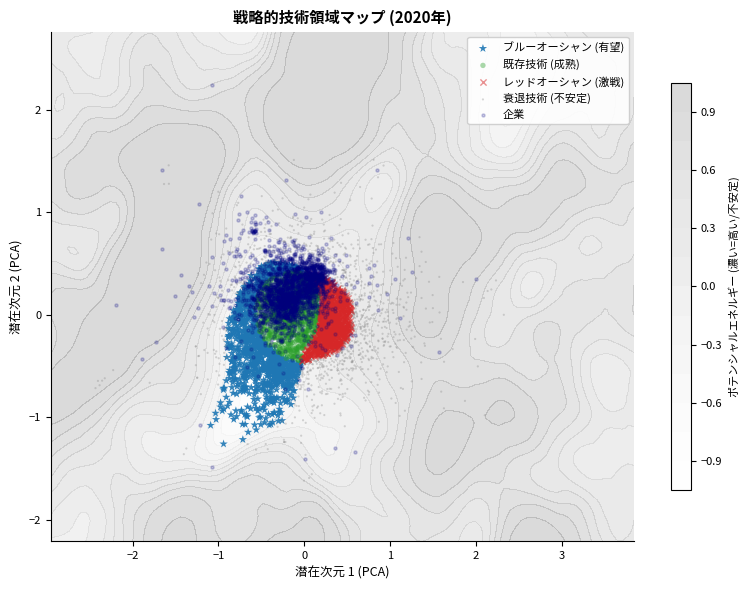

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (7.2, 5.0), # ダブルカラム幅に近い
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 統合可視化関数: 戦略的ランドスケープマップ
# ============================================================
def visualize_strategic_landscape_map(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 戦略的ランドスケープマップを作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # ポテンシャル値（全データ）
        potentials_all = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 特許データに基づく4象限分類 ---
    # 特許のみ抽出
    patent_indices = np.arange(num_corps, len(z_np))
    patent_z = z_np[patent_indices]
    patent_potentials = potentials_all[patent_indices]
    
    # PCA (2次元投影)
    pca = PCA(n_components=2)
    z_all_2d = pca.fit_transform(z_np) # 全体でPCA
    patent_z_2d = z_all_2d[patent_indices] # 特許部分のみ
    
    # 密度推定 (KDE)
    try:
        kde = gaussian_kde(patent_z_2d.T)
        patent_densities = kde(patent_z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # しきい値決定 (中央値)
    pot_thr = np.median(patent_potentials)
    den_thr = np.median(patent_densities)
    
    # 特許ごとの象限ラベル付け
    # 0: ブルーオーシャン (Pot:Low, Den:Low)
    # 1: 既存技術 (Pot:Low, Den:High)
    # 2: レッドオーシャン (Pot:High, Den:High)
    # 3: 衰退技術 (Pot:High, Den:Low)
    patent_labels = np.zeros(len(patent_indices), dtype=int)
    
    mask_blue = (patent_potentials <= pot_thr) & (patent_densities <= den_thr)
    mask_main = (patent_potentials <= pot_thr) & (patent_densities > den_thr)
    mask_red = (patent_potentials > pot_thr) & (patent_densities > den_thr)
    mask_decline = (patent_potentials > pot_thr) & (patent_densities <= den_thr)
    
    patent_labels[mask_blue] = 0
    patent_labels[mask_main] = 1
    patent_labels[mask_red] = 2
    patent_labels[mask_decline] = 3

    # --- 3. 背景のポテンシャル地形計算 ---
    x_min, x_max = z_all_2d[:, 0].min(), z_all_2d[:, 0].max()
    y_min, y_max = z_all_2d[:, 1].min(), z_all_2d[:, 1].max()
    margin = 0.5
    
    grid_res = 100
    grid_x = np.linspace(x_min - margin, x_max + margin, grid_res)
    grid_y = np.linspace(y_min - margin, y_max + margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        Z_pot = pot_net(grid_tensor).squeeze().cpu().numpy().reshape(X.shape)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 背景: ポテンシャル等高線 (薄く)
    contour = ax.contourf(X, Y, Z_pot, levels=15, cmap='Greys', alpha=0.15)
    
    # 色設定 (4象限分類と合わせる)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    labels = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退技術 (不安定)']
    markers = ['*', 'o', 'x', '.']
    sizes = [40, 15, 20, 10]
    alphas = [0.9, 0.4, 0.5, 0.3]
    
    # 象限ごとに特許をプロット
    for i in range(4):
        mask = (patent_labels == i)
        # データが多すぎる場合はサンプリング
        if np.sum(mask) > 1000:
            indices = np.where(mask)[0]
            sampled_indices = np.random.choice(indices, 1000, replace=False)
            p_z = patent_z_2d[sampled_indices]
        else:
            p_z = patent_z_2d[mask]
            
        ax.scatter(p_z[:, 0], p_z[:, 1], c=colors[i], label=labels[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], edgecolors='none')

    # 企業 (青い点, 透明度高め)
    corp_z_2d = z_all_2d[:num_corps]
    ax.scatter(corp_z_2d[:, 0], corp_z_2d[:, 1], c='navy', s=5, alpha=0.2, label='企業', zorder=1)

    # 凡例と装飾
    ax.legend(loc='upper right', frameon=True, framealpha=0.9)
    ax.set_title(f"戦略的技術領域マップ ({target_year}年)", fontweight='bold')
    ax.set_xlabel("潜在次元 1 (PCA)")
    ax.set_ylabel("潜在次元 2 (PCA)")
    
    # カラーバー (ポテンシャルの高低を示す)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('ポテンシャルエネルギー (濃い=高い/不安定)', fontsize=8)

    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_map.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_map.png', dpi=300)
    print("マップを保存しました: ./outputs/strategic_landscape_map.png")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_map(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )


[Evaluation] 戦略的ランドスケープ (地形なし・ベクトルのみ) を作成中...
保存完了: ./outputs/strategic_landscape_clean_vectors.png


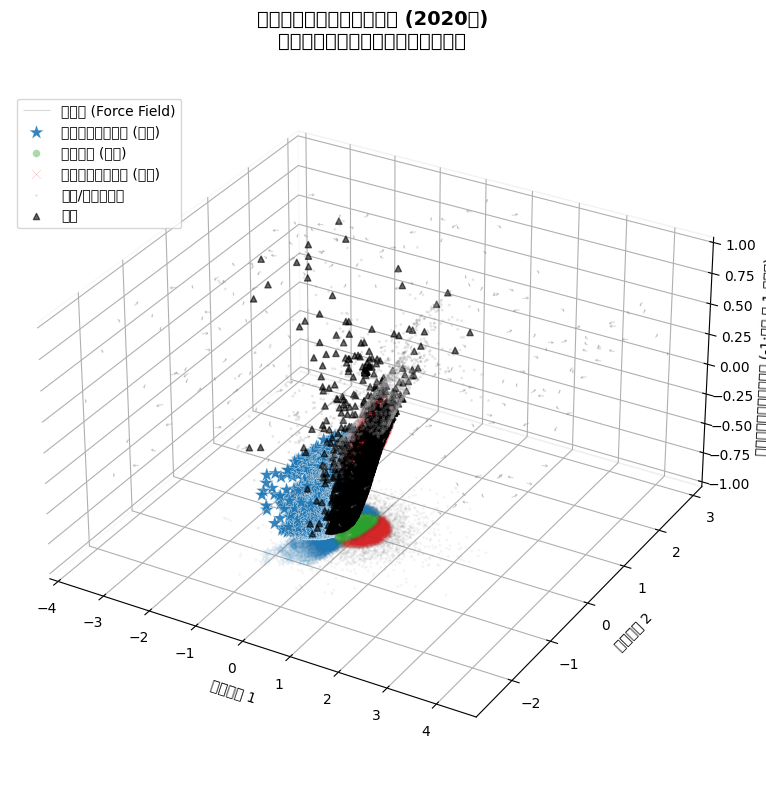

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch
import japanize_matplotlib # 日本語表示用

# ============================================================
# 1. Nature Style Configuration (3D + JP)
# ============================================================
def set_nature_style_3d_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 10,
        'savefig.dpi': 300,
        'figure.figsize': (10, 8),
        'svg.fonttype': 'none',
        # japanize_matplotlibが適用されるためフォント指定は省略
    })

# ============================================================
# 2. 統合可視化関数 (地形なし・ベクトルのみ)
# ============================================================
def visualize_strategic_landscape_clean(model, config, num_corps, device, year_idx=-1):
    set_nature_style_3d_jp()
    print("\n[Evaluation] 戦略的ランドスケープ (地形なし・ベクトルのみ) を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], diff), device=device)], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # 生のポテンシャル値
        potentials_raw = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 座標系構築 (PCA 2D) ---
    pca = PCA(n_components=2)
    xy_coords = pca.fit_transform(z_np)
    
    x_min, x_max = xy_coords[:, 0].min(), xy_coords[:, 0].max()
    y_min, y_max = xy_coords[:, 1].min(), xy_coords[:, 1].max()
    
    # --- 3. ベクトル場の計算 ---
    margin = 0.2
    x_range = x_max - x_min
    y_range = y_max - y_min
    grid_res = 30 # ベクトル描画用の解像度
    
    grid_x = np.linspace(x_min - x_range*margin, x_max + x_range*margin, grid_res)
    grid_y = np.linspace(y_min - y_range*margin, y_max + y_range*margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    grid_tensor.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor)
        grad = torch.autograd.grad(phi.sum(), grid_tensor, create_graph=False)[0]
    
    grad_np = grad.cpu().numpy()
    grad_2d = np.dot(grad_np, pca.components_.T)
    
    # ベクトル成分 (-勾配 = 安定方向への流れ)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z_raw_grid = phi.detach().cpu().numpy().reshape(X.shape)

    # --- 4. ポテンシャル正規化 (-1 ~ 1) ---
    all_z = np.concatenate([Z_raw_grid.flatten(), potentials_raw.flatten()])
    z_min_val, z_max_val = all_z.min(), all_z.max()
    
    def normalize_m1_1(val):
        # -1(谷/安定) 〜 1(山/不安定) に正規化
        return -1 + 2 * (val - z_min_val) / (z_max_val - z_min_val)

    Z_grid_norm = normalize_m1_1(Z_raw_grid)
    nodes_z_norm = normalize_m1_1(potentials_raw)

    # --- 5. 4象限分類ロジック (密度 & 正規化ポテンシャル) ---
    patent_indices = np.arange(num_corps, len(z_np))
    patent_xy = xy_coords[patent_indices]
    
    # 密度計算
    try:
        if len(patent_xy) > 5000:
            idx = np.random.choice(len(patent_xy), 5000, replace=False)
            kde = gaussian_kde(patent_xy[idx].T)
        else:
            kde = gaussian_kde(patent_xy.T)
        patent_densities = kde(patent_xy.T)
    except:
        patent_densities = np.zeros(len(patent_xy))

    # しきい値
    p_pot_norm = nodes_z_norm[patent_indices]
    pot_thr = np.median(p_pot_norm)
    den_thr = np.median(patent_densities)
    
    labels = np.zeros(len(patent_indices), dtype=int)
    
    # 0: ブルーオーシャン (Pot:Low[-1], Den:Low)
    labels[(p_pot_norm <= pot_thr) & (patent_densities <= den_thr)] = 0
    # 1: 既存技術 (Pot:Low[-1], Den:High)
    labels[(p_pot_norm <= pot_thr) & (patent_densities > den_thr)] = 1
    # 2: レッドオーシャン (Pot:High[1], Den:High)
    labels[(p_pot_norm > pot_thr) & (patent_densities > den_thr)] = 2
    # 3: 衰退/リスク (Pot:High[1], Den:Low)
    labels[(p_pot_norm > pot_thr) & (patent_densities <= den_thr)] = 3

    # ================= Plotting =================
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. ベクトル場 (地形なしで、空中に矢印だけ浮かべる)
    # 矢印の高さを、その地点のポテンシャルエネルギーに合わせる
    skip = 2 # 間引き
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_grid_norm[::skip, ::skip], 
              U[::skip, ::skip], V[::skip, ::skip], np.zeros_like(U[::skip, ::skip]), 
              length=0.1, normalize=True, color='gray', alpha=0.3, 
              arrow_length_ratio=0.4, linewidth=0.8, label='駆動力 (Force Field)')

    # B. 散布図 (4象限分類)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    names = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退/リスク領域']
    markers = ['*', 'o', 'x', '.']
    sizes = [120, 30, 40, 15] 
    alphas = [0.9, 0.4, 0.5, 0.2]
    
    z_floor = -1.0 # 床の高さ
    
    for i in range(4):
        mask = (labels == i)
        # 描画点数を制限
        if np.sum(mask) > 1500:
            indices = np.where(mask)[0]
            sampled = np.random.choice(indices, 1500, replace=False)
            px, py = patent_xy[sampled, 0], patent_xy[sampled, 1]
            pz = nodes_z_norm[patent_indices][sampled]
        else:
            px, py = patent_xy[mask, 0], patent_xy[mask, 1]
            pz = nodes_z_norm[patent_indices][mask]
            
        # データ点 (空中に浮いている)
        ax.scatter(px, py, pz, c=colors[i], label=names[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], 
                   depthshade=True, edgecolors='white', linewidth=0.2)
        
        # 床への影 (これが重要: 地形がないため、影で高さを認識させる)
        ax.scatter(px, py, np.full_like(pz, z_floor), 
                   c=colors[i], marker=markers[i], s=sizes[i]/3, alpha=0.05)

    # C. 企業 (黒い三角)
    c_idx = np.arange(num_corps)
    cx, cy = xy_coords[c_idx, 0], xy_coords[c_idx, 1]
    cz = nodes_z_norm[c_idx]
    ax.scatter(cx, cy, cz, c='black', label='企業', marker='^', s=20, alpha=0.6)

    # --- 見た目の調整 ---
    ax.set_title(f"戦略的技術ランドスケープ ({target_year}年)\n〜ベクトル場と市場ポテンシャル〜", 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('潜在変数 1')
    ax.set_ylabel('潜在変数 2')
    ax.set_zlabel('ポテンシャルエネルギー (-1:安定 〜 1:不安定)')
    
    # Z軸を -1 ~ 1 に固定
    ax.set_zlim(-1.0, 1.0)
    
    # 視点
    ax.view_init(elev=30, azim=-60)
    
    # 背景透明化
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_box_aspect((1, 1, 0.6))

    # 凡例
    plt.legend(loc='upper left', bbox_to_anchor=(0, 0.95), frameon=True)
    
    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_clean_vectors.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_clean_vectors.png', dpi=300)
    print("保存完了: ./outputs/strategic_landscape_clean_vectors.png")
    plt.show()

if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_clean(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )


[Evaluation] 戦略的ランドスケープ (3D統合版) を作成中...
保存完了: ./outputs/strategic_landscape_3d_integrated.png


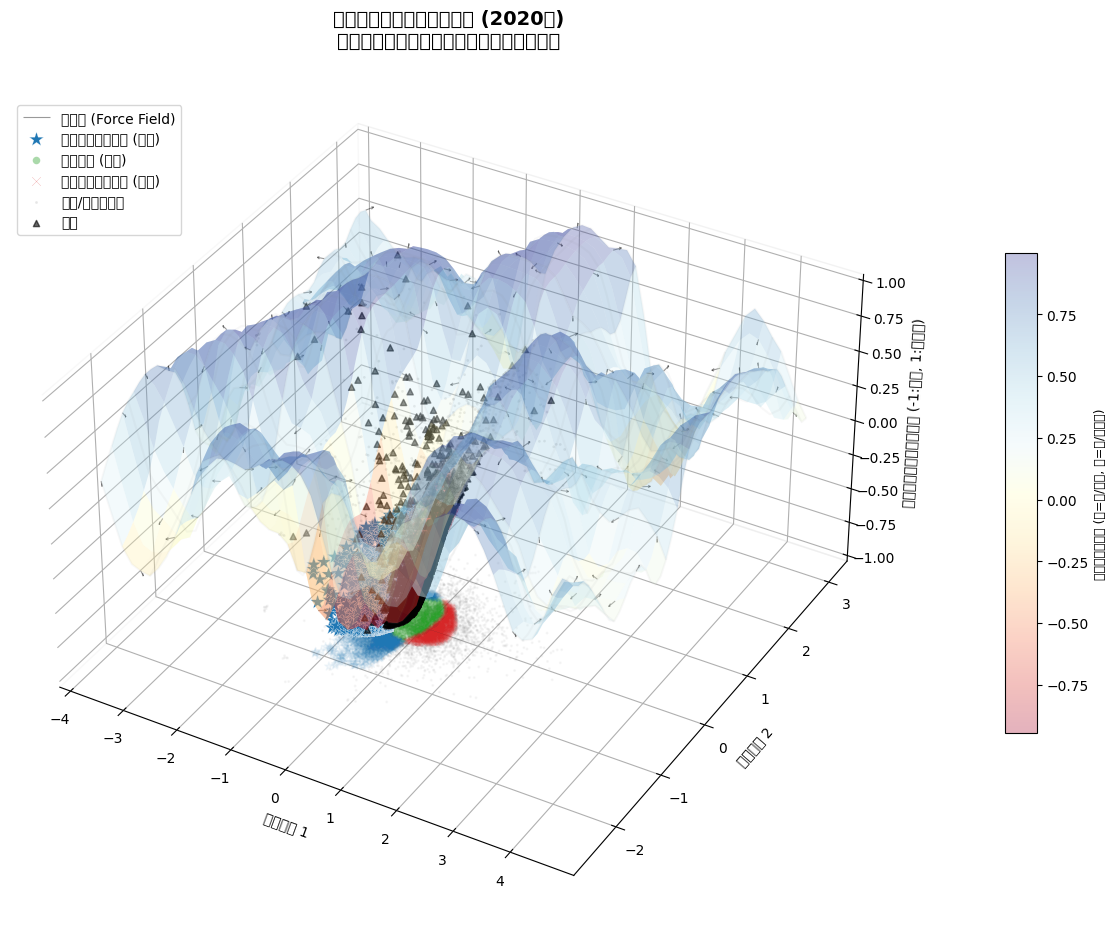

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import torch
import japanize_matplotlib # 日本語表示用

# ============================================================
# 1. Nature Style Configuration (3D + JP)
# ============================================================
def set_nature_style_3d_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 10,
        'savefig.dpi': 300,
        'figure.figsize': (10, 8),
        'svg.fonttype': 'none',
        # japanize_matplotlibが適用されるためフォント指定は省略可能ですが
        # 必要であれば以下のように指定
        # 'font.family': 'IPAexGothic',
    })

# ============================================================
# 2. 統合可視化関数 (3D + ベクトル + 4象限分類)
# ============================================================
def visualize_strategic_landscape_3d_integrated(model, config, num_corps, device, year_idx=-1):
    set_nature_style_3d_jp()
    print("\n[Evaluation] 戦略的ランドスケープ (3D統合版) を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], diff), device=device)], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # 生のポテンシャル値
        potentials_raw = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 座標系構築 (PCA 2D) ---
    pca = PCA(n_components=2)
    xy_coords = pca.fit_transform(z_np)
    
    x_min, x_max = xy_coords[:, 0].min(), xy_coords[:, 0].max()
    y_min, y_max = xy_coords[:, 1].min(), xy_coords[:, 1].max()
    
    # --- 3. ベクトル場 & 地形の計算 ---
    margin = 0.2
    x_range = x_max - x_min
    y_range = y_max - y_min
    grid_res = 50 # 解像度
    
    grid_x = np.linspace(x_min - x_range*margin, x_max + x_range*margin, grid_res)
    grid_y = np.linspace(y_min - y_range*margin, y_max + y_range*margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    grid_tensor.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor)
        grad = torch.autograd.grad(phi.sum(), grid_tensor, create_graph=False)[0]
    
    grad_np = grad.cpu().numpy()
    grad_2d = np.dot(grad_np, pca.components_.T)
    
    # ベクトル成分 (-勾配 = 谷へ下る方向)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z_raw_grid = phi.detach().cpu().numpy().reshape(X.shape)

    # --- 4. ポテンシャル正規化 (-1 ~ 1) ---
    all_z = np.concatenate([Z_raw_grid.flatten(), potentials_raw.flatten()])
    z_min_val, z_max_val = all_z.min(), all_z.max()
    
    def normalize_m1_1(val):
        return -1 + 2 * (val - z_min_val) / (z_max_val - z_min_val)

    Z_grid_norm = normalize_m1_1(Z_raw_grid)
    nodes_z_norm = normalize_m1_1(potentials_raw)

    # --- 5. 4象限分類ロジック (密度 & ポテンシャル) ---
    patent_indices = np.arange(num_corps, len(z_np))
    patent_xy = xy_coords[patent_indices]
    
    # 密度計算 (KDE)
    try:
        if len(patent_xy) > 5000:
            idx = np.random.choice(len(patent_xy), 5000, replace=False)
            kde = gaussian_kde(patent_xy[idx].T)
        else:
            kde = gaussian_kde(patent_xy.T)
        patent_densities = kde(patent_xy.T)
    except:
        patent_densities = np.zeros(len(patent_xy))

    # しきい値 (中央値)
    p_pot = potentials_raw[patent_indices] # 生の値で判定するのが安全
    pot_thr = np.median(p_pot)
    den_thr = np.median(patent_densities)
    
    labels = np.zeros(len(patent_indices), dtype=int)
    # 0: ブルーオーシャン (Pot:Low, Den:Low) -> 安定かつ空いている
    labels[(p_pot <= pot_thr) & (patent_densities <= den_thr)] = 0
    # 1: 既存技術 (Pot:Low, Den:High) -> 安定だが混んでいる
    labels[(p_pot <= pot_thr) & (patent_densities > den_thr)] = 1
    # 2: レッドオーシャン (Pot:High, Den:High) -> 不安定かつ混んでいる
    labels[(p_pot > pot_thr) & (patent_densities > den_thr)] = 2
    # 3: 衰退技術/リスク (Pot:High, Den:Low) -> 不安定かつ空いている
    labels[(p_pot > pot_thr) & (patent_densities <= den_thr)] = 3

    # ================= Plotting =================
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. 地形 (Surface) - 山=青, 谷=赤
    surf = ax.plot_surface(X, Y, Z_grid_norm, cmap='RdYlBu', alpha=0.3, 
                           linewidth=0, antialiased=True, rstride=2, cstride=2)
    
    # B. ワイヤーフレーム (形状強調)
    ax.plot_wireframe(X, Y, Z_grid_norm, color='gray', alpha=0.05, rstride=5, cstride=5)

    # C. ベクトル場 (矢印)
    skip = 4
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_grid_norm[::skip, ::skip], 
              U[::skip, ::skip], V[::skip, ::skip], np.zeros_like(U[::skip, ::skip]), 
              length=0.12, normalize=True, color='black', alpha=0.4, 
              arrow_length_ratio=0.3, linewidth=0.8, label='駆動力 (Force Field)')

    # D. 散布図 (4象限)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    names = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退/リスク領域']
    markers = ['*', 'o', 'x', '.']
    sizes = [120, 30, 40, 15] # ブルーオーシャンを強調
    alphas = [1.0, 0.4, 0.5, 0.2]
    
    z_floor = -1.0 # 床の高さ
    
    for i in range(4):
        mask = (labels == i)
        # 描画点数を制限して見やすくする
        if np.sum(mask) > 1500:
            indices = np.where(mask)[0]
            sampled = np.random.choice(indices, 1500, replace=False)
            px, py = patent_xy[sampled, 0], patent_xy[sampled, 1]
            pz = nodes_z_norm[patent_indices][sampled]
        else:
            px, py = patent_xy[mask, 0], patent_xy[mask, 1]
            pz = nodes_z_norm[patent_indices][mask]
            
        # データ点
        ax.scatter(px, py, pz, c=colors[i], label=names[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], 
                   depthshade=True, edgecolors='white', linewidth=0.2)
        
        # 床への影 (位置関係把握用)
        ax.scatter(px, py, np.full_like(pz, z_floor), 
                   c=colors[i], marker=markers[i], s=sizes[i]/3, alpha=0.05)

    # E. 企業 (黒い三角)
    c_idx = np.arange(num_corps)
    cx, cy = xy_coords[c_idx, 0], xy_coords[c_idx, 1]
    cz = nodes_z_norm[c_idx]
    ax.scatter(cx, cy, cz, c='black', label='企業', marker='^', s=20, alpha=0.6)

    # --- 見た目の調整 ---
    ax.set_title(f"戦略的技術ランドスケープ ({target_year}年)\n〜ポテンシャル場と市場密度による分析〜", 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('潜在変数 1')
    ax.set_ylabel('潜在変数 2')
    ax.set_zlabel('ポテンシャルエネルギー (-1:安定, 1:不安定)')
    ax.set_zlim(-1.0, 1.0)
    
    # 視点
    ax.view_init(elev=35, azim=-60)
    
    # 背景透明化
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_box_aspect((1, 1, 0.6))

    # カラーバー
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1)
    cbar.set_label('エネルギー準位 (赤=谷/安定, 青=山/不安定)', fontsize=9)

    plt.legend(loc='upper left', bbox_to_anchor=(0, 0.95), frameon=True)
    
    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_3d_integrated.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_3d_integrated.png', dpi=300)
    print("保存完了: ./outputs/strategic_landscape_3d_integrated.png")
    plt.show()

if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_3d_integrated(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )

Loading data from ../dataset/topic_info3.csv...
Training Standard GODE...
Epoch 1/15 | Loss: 23.5525
Epoch 2/15 | Loss: 11.4278
Epoch 3/15 | Loss: 8.7772
Epoch 4/15 | Loss: 7.2759
Epoch 5/15 | Loss: 7.2415
Epoch 6/15 | Loss: 7.0361
Epoch 7/15 | Loss: 6.9904
Epoch 8/15 | Loss: 6.9772
Epoch 9/15 | Loss: 6.9264
Epoch 10/15 | Loss: 6.9283
Epoch 11/15 | Loss: 6.8997
Epoch 12/15 | Loss: 6.9468
Epoch 13/15 | Loss: 6.9271
Epoch 14/15 | Loss: 6.9376
Epoch 15/15 | Loss: 6.9232

Visualizing Year: 2020

Generating Vector Field for Standard GODE (SVG Output)...
Visualization saved to ./standard_ode_vector_field_2020.svg


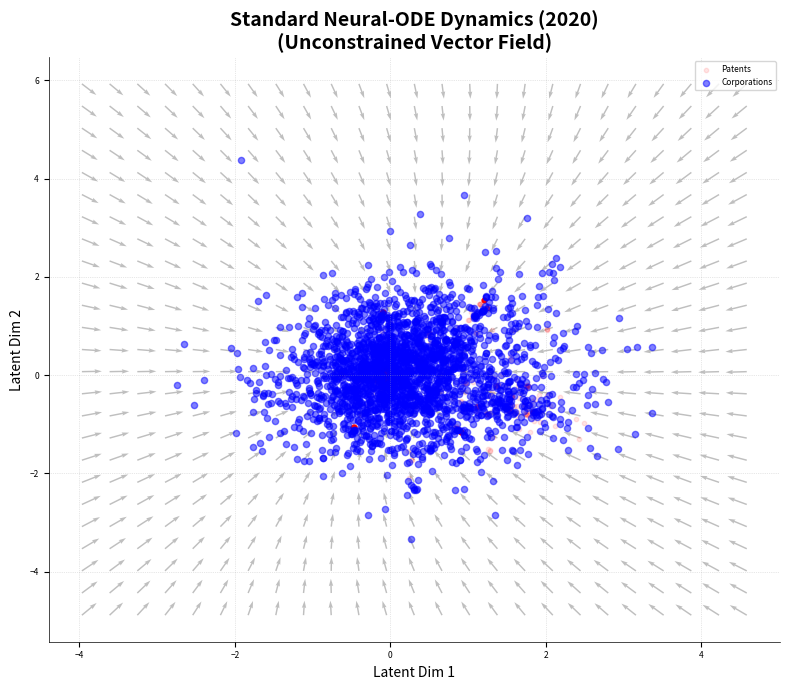

In [24]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
import os

# ============================================================
# 基本設定
# ============================================================
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理 & グラフ構築
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except: return None
    return None

def preprocess_and_build_graphs(file_path):
    print(f"Loading data from {file_path}...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return None, None, None, None

    combined_vectors = []
    valid_indices = []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
    
    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try: return ast.literal_eval(x) if isinstance(x, str) else x
        except: return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]

    # グラフ構築
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    for year, group in df.groupby(df['year_month'].dt.year):
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx])
                    edges.append([p_idx, c_idx])
        
        if not edges: continue
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, num_nodes=total_nodes)

    return global_graph_dict, len(all_corporations), total_nodes, input_dim

# ============================================================
# 2. モデル定義 (Standard GODE & Encoder)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def get_node_features(self, x):
        features = x.clone()
        node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return z, mu, logvar

    def predict_future(self, z_curr):
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4')[-1]
        return z_next

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

# ============================================================
# 3. 学習関数 (Standard GODE専用)
# ============================================================
def train_standard_ode(model, graphs, num_epochs=15):
    print("Training Standard GODE...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    years = sorted(graphs.keys())
    train_years = years[:-1]

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for i in range(len(train_years) - 1):
            y_t = train_years[i]
            y_next = train_years[i+1]
            data_t = graphs[y_t].to(device)
            data_next = graphs[y_next].to(device)

            optimizer.zero_grad()
            
            # Encode & Recon
            z_t, _, _ = model.encode(data_t.x, data_t.edge_index)
            pos_pred = model.decode(z_t, data_t.edge_index)
            neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
            neg_pred = model.decode(z_t, neg_idx)
            recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
            
            # Future Prediction (MSE)
            # Standard ODEは「何でもあり」の動きをするため、この項で無理やり合わせようとする
            z_pred = model.predict_future(z_t)
            with torch.no_grad():
                _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
            
            # MSE Loss
            loss_pred = F.mse_loss(z_pred, mu_next)
            
            total_loss = recon_loss + loss_pred
            total_loss.backward()
            optimizer.step()
            epoch_loss += total_loss.item()
            
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}")
    
    return model

# ============================================================
# 4. 可視化関数 (ベクトル場 - SVG保存)
# ============================================================
def visualize_standard_ode_2d(model, data, num_corps, device):
    print("\nGenerating Vector Field for Standard GODE (SVG Output)...")
    model.eval()
    data = data.to(device)
    
    # 1. Encode
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            x_input = torch.cat([x_input, torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. PCA
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # 3. Grid
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    resolution = 25
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    # 4. Vector Field (dz/dt)
    with torch.no_grad():
        dz_dt = model.ode_func_module(torch.tensor(0.0), grid_tensor)
    
    dz_dt_2d = np.dot(dz_dt.cpu().numpy(), pca.components_.T)
    U = dz_dt_2d[:, 0].reshape(X.shape)
    V = dz_dt_2d[:, 1].reshape(X.shape)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Quiver (ベクトル場)
    ax.quiver(X, Y, U, V, color='gray', alpha=0.5, angles='xy', scale_units='xy', width=0.002)
    
    # Scatter (データ点)
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='red', alpha=0.1, s=10, label='Patents')
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.5, s=20, label='Corporations')

    ax.set_title("Standard Neural-ODE Dynamics (2020)\n(Unconstrained Vector Field)", fontsize=14, fontweight='bold')
    ax.set_xlabel('Latent Dim 1', fontsize=10)
    ax.set_ylabel('Latent Dim 2', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # === SVGで保存 ===
    save_path = './standard_ode_vector_field_2020.svg' # ファイル名に2020を追加
    plt.tight_layout()
    plt.savefig(save_path, format='svg', bbox_inches='tight')
    print(f"Visualization saved to {save_path}")
    plt.show()

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # データパスを指定してください
    DATA_PATH = '../dataset/topic_info3.csv' 
    
    if os.path.exists(DATA_PATH):
        # 1. Load Data
        graphs, num_corps, total_n, in_dim = preprocess_and_build_graphs(DATA_PATH)
        
        if graphs:
            # 2. Initialize Model
            model = StandardGODE(total_n, num_corps, in_dim, hidden_dim=64, latent_dim=16).to(device)
            
            # 3. Train
            model = train_standard_ode(model, graphs, num_epochs=15)
            
            # 4. Visualize (Target Year: 2020)
            target_year = 2020
            
            if target_year in graphs:
                print(f"\nVisualizing Year: {target_year}")
                visualize_standard_ode_2d(model, graphs[target_year], num_corps, device)
            else:
                print(f"\nWarning: Year {target_year} not found in data. Available years: {list(graphs.keys())}")
                # データがない場合は最後の年を表示
                last_year = max(graphs.keys())
                print(f"Fallback to visualization for year: {last_year}")
                visualize_standard_ode_2d(model, graphs[last_year], num_corps, device)
    else:
        print(f"File not found: {DATA_PATH}. Please check the path.")